<a href="https://colab.research.google.com/github/Gauranggupta2323/Gaurang_Gupta_JECRC_Foundation_CEI/blob/main/CIFAR10_ANN_CNN_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project



### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [10]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

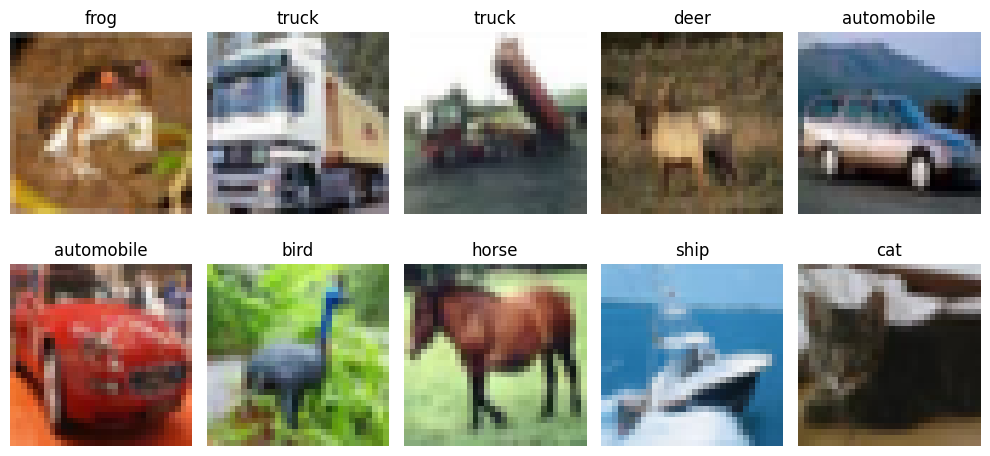

In [11]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [12]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [14]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:


ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann_history = ann_model.fit(x_train_flat, y_train, epochs=20, validation_split=0.1, batch_size=64, callbacks=[early_stop])

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.3264 - loss: 1.9173 - val_accuracy: 0.3202 - val_loss: 1.9028
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.3924 - loss: 1.6915 - val_accuracy: 0.3956 - val_loss: 1.7015
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.4134 - loss: 1.6331 - val_accuracy: 0.3804 - val_loss: 1.7321
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.4218 - loss: 1.6124 - val_accuracy: 0.3984 - val_loss: 1.6766
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.4275 - loss: 1.5929 - val_accuracy: 0.3948 - val_loss: 1.6840
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.4344 - loss: 1.5764 - val_accuracy: 0.4754 - val_loss: 1.4689
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.4377 - loss: 1.5713 - val_accuracy: 0.3848 - val_loss: 1.7264
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.4386 - loss: 1.5655 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4209 - loss: 1.6440
ANN Test Accuracy: 0.42089998722076416


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [17]:

cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3), padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_history = cnn_model.fit(x_train_norm, y_train, epochs=20, validation_split=0.1, batch_size=64, callbacks=[early_stop])



Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 107s 149ms/step - accuracy: 0.4148 - loss: 1.6593 - val_accuracy: 0.5110 - val_loss: 1.3574
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 106s 151ms/step - accuracy: 0.5681 - loss: 1.2180 - val_accuracy: 0.5444 - val_loss: 1.3329
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 105s 149ms/step - accuracy: 0.6445 - loss: 1.0250 - val_accuracy: 0.6442 - val_loss: 0.9905
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 144ms/step - accuracy: 0.6959 - loss: 0.8833 - val_accuracy: 0.6908 - val_loss: 0.8860
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 146ms/step - accuracy: 0.7319 - loss: 0.7819 - val_accuracy: 0.6566 - val_loss: 1.0680
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 103s 146ms/step - accuracy: 0.7599 - loss: 0.6889 - val_accuracy: 0.7300 - val_loss: 0.7785
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 104s 148ms/step - accuracy: 0.7886 - loss: 0.6153 - val_accuracy: 0.6950 - val_loss: 1.0251
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 144ms/step - accuracy: 0.8101 -

In [18]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7828 - loss: 0.7288
CNN Test Accuracy: 0.782800018787384


## 📈 Compare Learning Curves

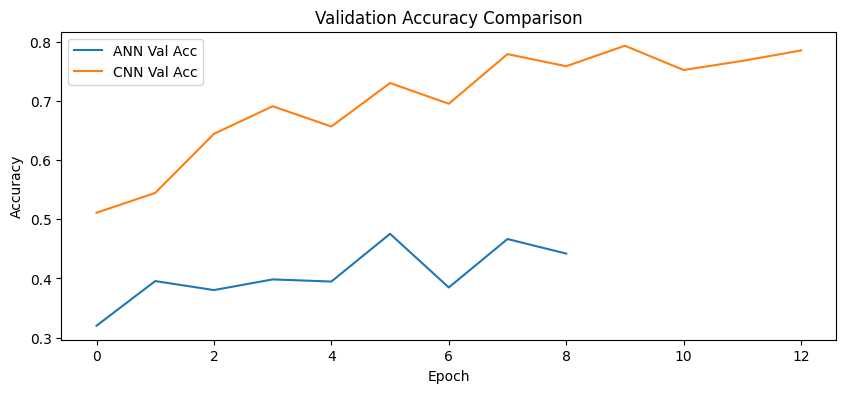

In [20]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history.get('val_accuracy', []), label='ANN Val Acc')
plt.plot(cnn_history.history.get('val_accuracy', []), label='CNN Val Acc')
if 'aug_history' in globals():
	plt.plot(aug_history.history.get('val_accuracy', []), label='CNN+Aug Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [22]:



data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])
aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(64, 3, activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
aug_cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=20, validation_split=0.1, batch_size=64, callbacks=[early_stop])

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 140ms/step - accuracy: 0.3169 - loss: 1.9066 - val_accuracy: 0.4480 - val_loss: 1.4879
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.4030 - loss: 1.6355 - val_accuracy: 0.5070 - val_loss: 1.3727
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 138ms/step - accuracy: 0.4494 - loss: 1.5323 - val_accuracy: 0.5472 - val_loss: 1.2863
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 108s 153ms/step - accuracy: 0.4793 - loss: 1.4478 - val_accuracy: 0.5620 - val_loss: 1.2402
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 142ms/step - accuracy: 0.5003 - loss: 1.4012 - val_accuracy: 0.5898 - val_loss: 1.1407
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 140ms/step - accuracy: 0.5198 - loss: 1.3555 - val_accuracy: 0.5474 - val_loss: 1.2889
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 101s 143ms/step - accuracy: 0.5380 - loss: 1.3088 - val_accuracy: 0.5638 - val_loss: 1.3034
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 142ms/step - accuracy: 0.5494 - l

In [23]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("CNN+Aug Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5909 - loss: 1.1559
CNN+Aug Test Accuracy: 0.5909000039100647


# 📊 Final Comparison Table

In [24]:
comparison = pd.DataFrame({
    "Model": ["ANN (deep)", "CNN (deeper)", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN (deep),0.4209
1,CNN (deeper),0.7828
2,CNN + Augmentation,0.5909
